In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style='whitegrid')
dataset = pd.read_csv('./mydata.csv')
dataset.head()

,date,clock,stadium,class,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,...,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red,links
0,28th May 2023,4:30pm,Emirates Stadium,h,"60,095",2,5,13,0,51.0,...,52.2,0,3,8,11,0,0,0,0,https://www.skysports.com/football/arsenal-vs-...
1,28th May 2023,4:30pm,Villa Park,h,"42,212",7,2,6,1,40.3,...,47.8,3,3,15,16,4,4,0,0,https://www.skysports.com/football/aston-villa...
2,28th May 2023,4:30pm,Gtech Community Stadium,h,"17,120",9,1,1,0,34.4,...,50.0,2,3,12,8,4,0,0,0,https://www.skysports.com/football/brentford-v...
3,28th May 2023,4:30pm,Stamford Bridge,d,"40,130",12,1,4,1,64.4,...,45.5,3,5,9,11,0,0,0,0,https://www.skysports.com/football/chelsea-vs-...
4,28th May 2023,4:30pm,Selhurst Park,d,"25,198",11,1,16,1,66.0,...,41.7,3,2,9,13,0,2,0,0,https://www.skysports.com/football/crystal-pal...


In [14]:
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

here, we aim to see if there is any meaningful correlation between the result of a match and other contributing factors.
first, we convert dates and times to datatypes that we can work with.
we remove the links, and stadium names (since home/away information is already captured in the class column).

In [2]:
dataset['date'] = pd.to_datetime(dataset['date'], errors='coerce')
dataset['attendance'] = dataset['attendance'].str.replace(',','').astype(float)


In [3]:
dataset['clock'] = pd.to_datetime(dataset['clock'], errors='coerce')
dataset = dataset.drop(columns=['links', 'stadium'])

C:\Users\USER\AppData\Local\Temp\ipykernel_18668\3254765873.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset['clock'] = pd.to_datetime(dataset['clock'], errors='coerce')


In [4]:
dataset['class'].value_counts()

class
h    494
a    390
d    256
Name: count, dtype: int64

this is a classification problem, and i will choose to use a one-vs-one model since there are only 3C2 = 3 comparisons to be made,
and it is reasonable to assume that there will be significant overlap between a draw and a loss, for example.

i am tempted to remove date in the dataset, since it has many naT values. intuitively, the particular date should not have an impact on performance. i also don't want time in there as datetime complicates the variables. let's try testing the correlation between these two features, and y.

In [5]:
testdataset = dataset.dropna(axis=0) #remove all the invalid dates
from skrub import DatetimeEncoder
dtenc = DatetimeEncoder()
Xd = pd.concat([dtenc.fit_transform(testdataset['date']), dtenc.fit_transform(testdataset['clock'])], axis =1)
yd = testdataset['class']
Xd_train, Xd_test, yd_train, yd_test = sklearn.model_selection.train_test_split(Xd, yd, test_size=0.3, random_state=4, stratify=yd)
logmod = sklearn.linear_model.LogisticRegression()
ovologmod = sklearn.multiclass.OneVsOneClassifier(logmod)
resd = ovologmod.fit(Xd_train, yd_train)
yd_hat = resd.predict(Xd_test)
print(sklearn.metrics.classification_report(yd_test,yd_hat, labels=yd_test.unique(),zero_division=0.0))


              precision    recall  f1-score   support

           d       0.00      0.00      0.00        36
           a       0.00      0.00      0.00        57
           h       0.47      1.00      0.64        81

    accuracy                           0.47       174
   macro avg       0.16      0.33      0.21       174
weighted avg       0.22      0.47      0.30       174



clearly date and time are not very good at predicting win-loss - it predicted all home wins!
let's remove date from the dataset.

In [6]:
dataset = dataset.drop(columns=['date', 'clock'])
dataset.head()

,class,attendance,Home Team,Goals Home,Away Team,Away Goals,home_possessions,away_possessions,home_shots,away_shots,...,home_duels,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red
0,h,60095.0,2,5,13,0,51.0,49.0,14,6,...,47.8,52.2,0,3,8,11,0,0,0,0
1,h,42212.0,7,2,6,1,40.3,59.7,12,8,...,52.2,47.8,3,3,15,16,4,4,0,0
2,h,17120.0,9,1,1,0,34.4,65.6,11,17,...,50.0,50.0,2,3,12,8,4,0,0,0
3,d,40130.0,12,1,4,1,64.4,35.6,22,13,...,54.5,45.5,3,5,9,11,0,0,0,0
4,d,25198.0,11,1,16,1,66.0,34.0,15,7,...,58.3,41.7,3,2,9,13,0,2,0,0


we reinspect our columns - teams are not continuous variables! we use one hot encoding to fix this

In [7]:
onehotenc = sklearn.preprocessing.OneHotEncoder(handle_unknown='ignore')
home_teams_nw = pd.DataFrame(onehotenc.fit_transform(dataset[['Home Team']]).todense())
home_teams_nw.columns = [f'ht_{i}' for i in range(25)]
away_teams_nw = pd.DataFrame(onehotenc.fit_transform(dataset[['Away Team']]).todense())
away_teams_nw.columns = [f'at_{i}' for i in range(25)]
dataset = pd.concat([home_teams_nw, away_teams_nw, dataset.drop(columns=['Home Team', 'Away Team'])], axis=1)
dataset

,ht_0,ht_1,ht_2,ht_3,ht_4,ht_5,ht_6,ht_7,ht_8,ht_9,...,home_duels,away_duels,home_saves,away_saves,home_fouls,away_fouls,home_yellow,away_yellow,home_red,away_red
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,47.8,52.2,0,3,8,11,0,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,52.2,47.8,3,3,15,16,4,4,0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,50.0,50.0,2,3,12,8,4,0,0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,54.5,45.5,3,5,9,11,0,0,0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,58.3,41.7,3,2,9,13,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,64.0,36.0,4,1,12,9,1,1,0,0
1136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,40.5,59.5,0,3,13,7,2,2,0,0
1137,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,53.8,46.2,0,3,9,6,1,0,0,0
1138,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,50.0,50.0,5,2,14,11,2,1,0,0


we see that the order of magnitude for tackles is in the 10s, but goals are in the 1s. let's scale these features appropraitely. We then use logistic regression to predict our data.

In [41]:
X = dataset.drop(columns=['class'])
y = dataset[['class']]

In [73]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.3)
preprocessor = sklearn.compose.ColumnTransformer(
    [('stdscaler', sklearn.preprocessing.StandardScaler(), np.arange(50, X.shape[1]))],
    remainder='passthrough'
)
#we use a l1 penalty since we may expect some variables to be zero
pipe = sklearn.pipeline.Pipeline(steps=[
    ('transformer', preprocessor),
    ('logreg', sklearn.linear_model.LogisticRegression(penalty='l1', solver='saga', max_iter=5000)),
])
pipe_ovo = sklearn.multiclass.OneVsOneClassifier(pipe)
res = pipe_ovo.fit(X_train, y_train)
yhat = res.predict(X_test)
sklearn.metrics.zero_one_loss(y_test, yhat)

0.00877192982456143

our model is correct 99% of the time.

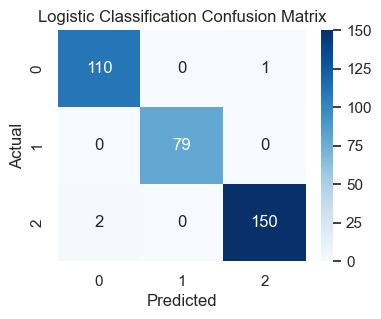

In [74]:
log_mod_cm = sklearn.metrics.confusion_matrix(y_test, yhat)
plt.figure(figsize=(4,3))
sns.heatmap(log_mod_cm, annot=True, cmap='Blues', fmt='d')
plt.title("Logistic Classification Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Logistic Regression is rather proficient at predicting results. Let's try another more complex method, gradient boosting.

In [75]:
g_pipe = sklearn.pipeline.Pipeline(steps=[
    ('transformer', preprocessor),
    ('gboost', sklearn.ensemble.GradientBoostingClassifier()),
])
g_pipe_ovo = sklearn.multiclass.OneVsOneClassifier(pipe)
g_res = pipe_ovo.fit(X_train, y_train)
g_yhat = res.predict(X_test)
sklearn.metrics.zero_one_loss(y_test, g_yhat)

0.00877192982456143

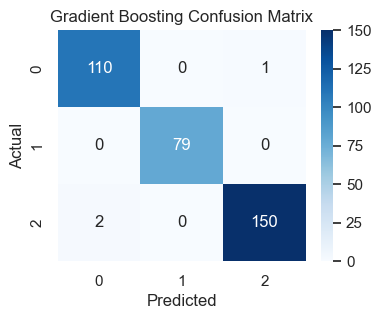

In [77]:
g_boost_cm = sklearn.metrics.confusion_matrix(y_test, g_yhat)
plt.figure(figsize=(4,3))
sns.heatmap(g_boost_cm, annot=True, cmap='Blues', fmt='d')
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Gradient Boosting performed similarly to logistic regression, but it suffers from being less interpretable.